# 01 — Exploratory Data Analysis

Explore the StatsBomb shot dataset: distributions, base rates, data quality, and pitch visualisations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

df = pd.read_parquet("../data/raw/shots_raw.parquet")
print(f"Total shots: {len(df):,}")
print(f"Total goals: {df['shot_outcome'].eq('Goal').sum():,}")
print(f"Goal rate: {df['shot_outcome'].eq('Goal').mean():.1%}")
print(f"Columns: {len(df.columns)}")
df.head()

Total shots: 88,023
Total goals: 9,790
Goal rate: 11.1%
Columns: 126


,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_penalty,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,...,shot_deflected,pass_miscommunication,pass_no_touch,goalkeeper_punched_out,pass_straight,shot_open_goal,dribble_no_touch,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_shot_saved_to_post,shot_saved_to_post,clearance_other,goalkeeper_success_out,goalkeeper_success_in_play,shot_redirect,goalkeeper_lost_out,shot_follows_dribble,half_start_late_video_start,player_off_permanent,pass_backheel,goalkeeper_lost_in_play,half_end_early_video_end,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,shot_kick_off
0,None,NaN,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,0.052872,None,NaN,None,None,None,None,NaN,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,None,NaN,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,0.217872,None,NaN,None,None,None,None,NaN,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,None,NaN,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,0.445768,None,NaN,None,None,None,None,NaN,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,None,NaN,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,0.085298,None,NaN,None,None,None,None,NaN,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,None,NaN,NaN,None,None,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,0.402989,None,NaN,None,None,None,None,NaN,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


## Dataset overview

                         shots  goals  goal_rate
competition                                     
La Liga                  21210   2658   0.125318
Premier League           10837   1082   0.099843
Ligue 1                  10346   1105   0.106805
Serie A                  10033    955   0.095186
1. Bundesliga             8747    947   0.108266
FA Women's Super League   8321    962   0.115611
FIFA World Cup            3904    443   0.113473
Indian Super league       3095    345   0.111470
Women's World Cup         2994    327   0.109218
UEFA Euro                 2629    281   0.106885
UEFA Women's Euro         1793    214   0.119353
African Cup of Nations    1244    159   0.127814
NWSL                      1041    102   0.097983
Copa America               790     95   0.120253
Champions League           594     74   0.124579
Major League Soccer        146     12   0.082192
UEFA Europa League          89      8   0.089888
Copa del Rey                74      8   0.108108
Liga Profesional    

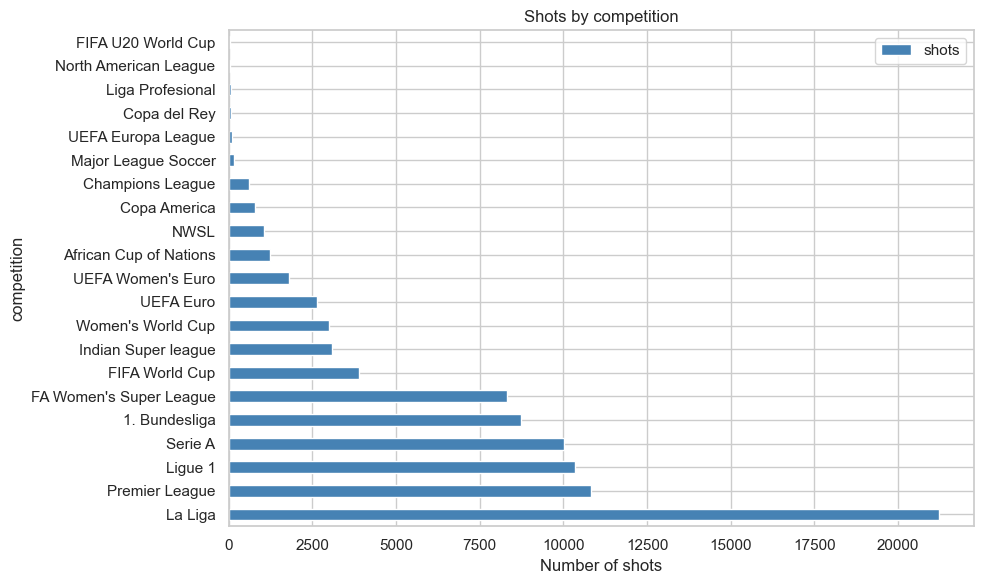

In [2]:
# Shots and goals by competition
comp_stats = (
    df.groupby("competition")
    .agg(
        shots=("shot_outcome", "count"),
        goals=("shot_outcome", lambda x: (x == "Goal").sum()),
    )
    .assign(goal_rate=lambda x: x["goals"] / x["shots"])
    .sort_values("shots", ascending=False)
)
print(comp_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
comp_stats.plot.barh(y="shots", ax=ax, color="steelblue")
ax.set_xlabel("Number of shots")
ax.set_title("Shots by competition")
plt.tight_layout()
plt.show()

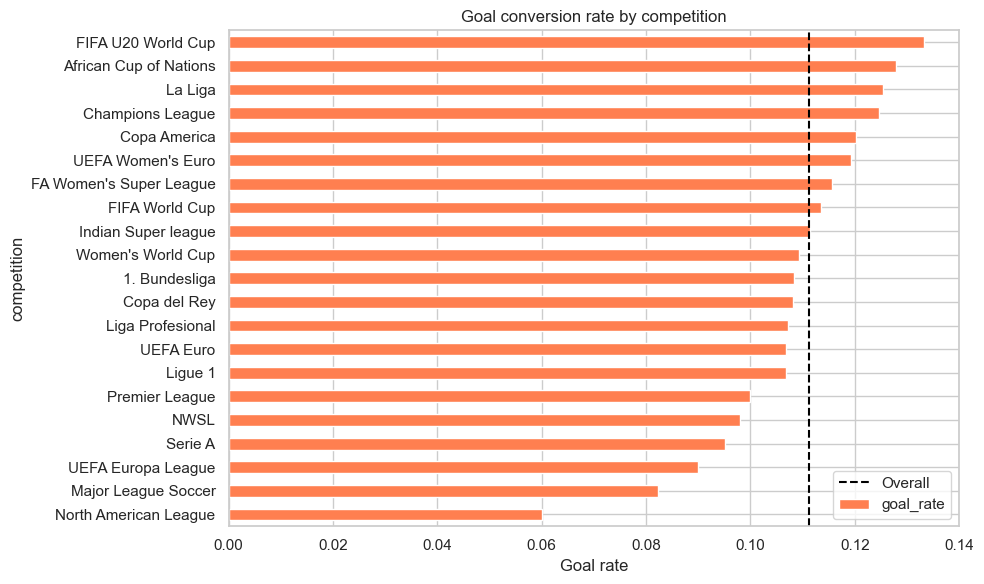

In [3]:
# Goal rate by competition
fig, ax = plt.subplots(figsize=(10, 6))
comp_stats.sort_values("goal_rate").plot.barh(y="goal_rate", ax=ax, color="coral")
ax.axvline(df["shot_outcome"].eq("Goal").mean(), color="black", linestyle="--", label="Overall")
ax.set_xlabel("Goal rate")
ax.set_title("Goal conversion rate by competition")
ax.legend()
plt.tight_layout()
plt.show()

## Column exploration & data quality

In [4]:
# Check available columns and missing values
shot_cols = [c for c in df.columns if c.startswith("shot_") or c in ["location", "under_pressure", "play_pattern"]]
print("Key shot columns:")
for col in sorted(shot_cols):
    non_null = df[col].notna().sum()
    pct = non_null / len(df) * 100
    print(f"  {col:40s} {non_null:>6,} / {len(df):,} ({pct:.1f}%)")

Key shot columns:
  location                                 88,023 / 88,023 (100.0%)
  play_pattern                             88,023 / 88,023 (100.0%)
  shot_aerial_won                           7,306 / 88,023 (8.3%)
  shot_body_part                           88,023 / 88,023 (100.0%)
  shot_deflected                            1,152 / 88,023 (1.3%)
  shot_end_location                        88,023 / 88,023 (100.0%)
  shot_first_time                          26,650 / 88,023 (30.3%)
  shot_follows_dribble                         71 / 88,023 (0.1%)
  shot_freeze_frame                        86,833 / 88,023 (98.6%)
  shot_key_pass_id                         62,012 / 88,023 (70.4%)
  shot_kick_off                                 1 / 88,023 (0.0%)
  shot_one_on_one                           4,661 / 88,023 (5.3%)
  shot_open_goal                              945 / 88,023 (1.1%)
  shot_outcome                             88,023 / 88,023 (100.0%)
  shot_redirect                              

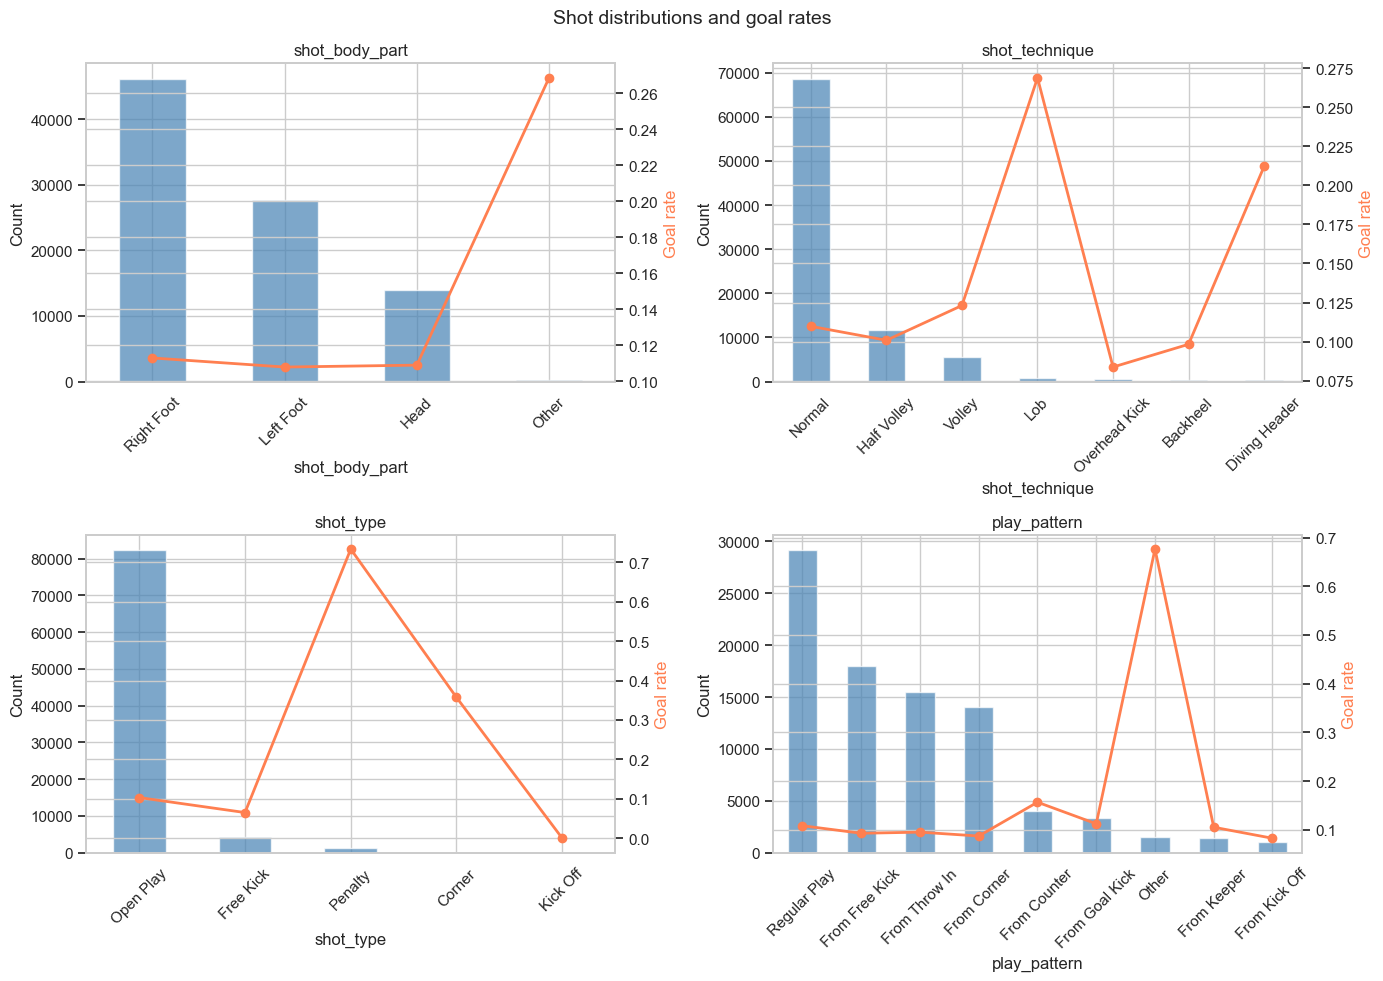

In [5]:
# Distribution of key categorical fields
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, ["shot_body_part", "shot_technique", "shot_type", "play_pattern"]):
    if col in df.columns:
        counts = df[col].value_counts()
        goal_rates = df.groupby(col)["shot_outcome"].apply(lambda x: (x == "Goal").mean())
        goal_rates = goal_rates.reindex(counts.index)
        
        ax2 = ax.twinx()
        counts.plot.bar(ax=ax, color="steelblue", alpha=0.7)
        goal_rates.plot(ax=ax2, color="coral", marker="o", linewidth=2)
        ax.set_title(col)
        ax.set_ylabel("Count")
        ax2.set_ylabel("Goal rate", color="coral")
        ax.tick_params(axis="x", rotation=45)

plt.suptitle("Shot distributions and goal rates", fontsize=14)
plt.tight_layout()
plt.show()

## Shot locations on the pitch

Valid locations: 88,023 / 88,023


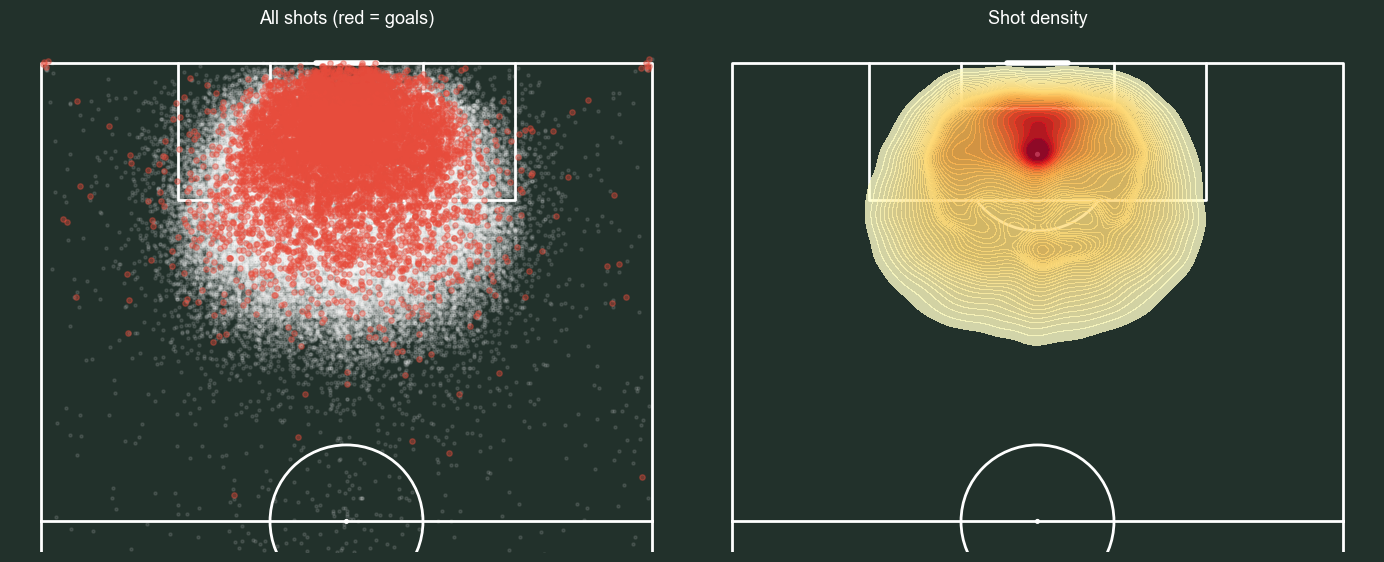

In [6]:
# Parse location coordinates
# StatsBomb locations are [x, y] in a 120x80 yard pitch
# Stored as numpy arrays in parquet
df["x"] = df["location"].apply(lambda loc: float(loc[0]) if hasattr(loc, '__len__') else np.nan)
df["y"] = df["location"].apply(lambda loc: float(loc[1]) if hasattr(loc, '__len__') else np.nan)

print(f"Valid locations: {df['x'].notna().sum():,} / {len(df):,}")

is_goal = df["shot_outcome"] == "Goal"

pitch = VerticalPitch(pitch_type="statsbomb", half=True, pitch_color="#22312b", line_color="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# All shots
pitch.draw(ax=axes[0])
pitch.scatter(df.loc[~is_goal, "x"], df.loc[~is_goal, "y"], ax=axes[0], s=5, color="white", alpha=0.1)
pitch.scatter(df.loc[is_goal, "x"], df.loc[is_goal, "y"], ax=axes[0], s=15, color="#e74c3c", alpha=0.4)
axes[0].set_title("All shots (red = goals)", color="white", fontsize=13)

# Shot density heatmap
pitch.draw(ax=axes[1])
pitch.kdeplot(df["x"].dropna(), df["y"].dropna(), ax=axes[1], fill=True, cmap="YlOrRd", levels=50, alpha=0.8)
axes[1].set_title("Shot density", color="white", fontsize=13)

fig.set_facecolor("#22312b")
plt.tight_layout()
plt.show()

## Distance and angle analysis

In [7]:
# Calculate distance to goal centre and angle
# StatsBomb pitch: 120 x 80 yards, goal at x=120, centred at y=40
GOAL_X = 120
GOAL_CENTRE_Y = 40
GOAL_WIDTH = 8  # yards (approx)

df["distance_to_goal"] = np.sqrt((GOAL_X - df["x"]) ** 2 + (GOAL_CENTRE_Y - df["y"]) ** 2)

# Angle: visible angle of goal from shot position
goal_left_y = GOAL_CENTRE_Y - GOAL_WIDTH / 2
goal_right_y = GOAL_CENTRE_Y + GOAL_WIDTH / 2

angle_left = np.arctan2(goal_left_y - df["y"], GOAL_X - df["x"])
angle_right = np.arctan2(goal_right_y - df["y"], GOAL_X - df["x"])
df["angle_to_goal"] = np.abs(angle_right - angle_left)
df["angle_to_goal_deg"] = np.degrees(df["angle_to_goal"])

print(f"Distance — mean: {df['distance_to_goal'].mean():.1f} yds, median: {df['distance_to_goal'].median():.1f} yds")
print(f"Angle — mean: {df['angle_to_goal_deg'].mean():.1f}°, median: {df['angle_to_goal_deg'].median():.1f}°")

Distance — mean: 19.2 yds, median: 18.4 yds
Angle — mean: 25.4°, median: 19.8°


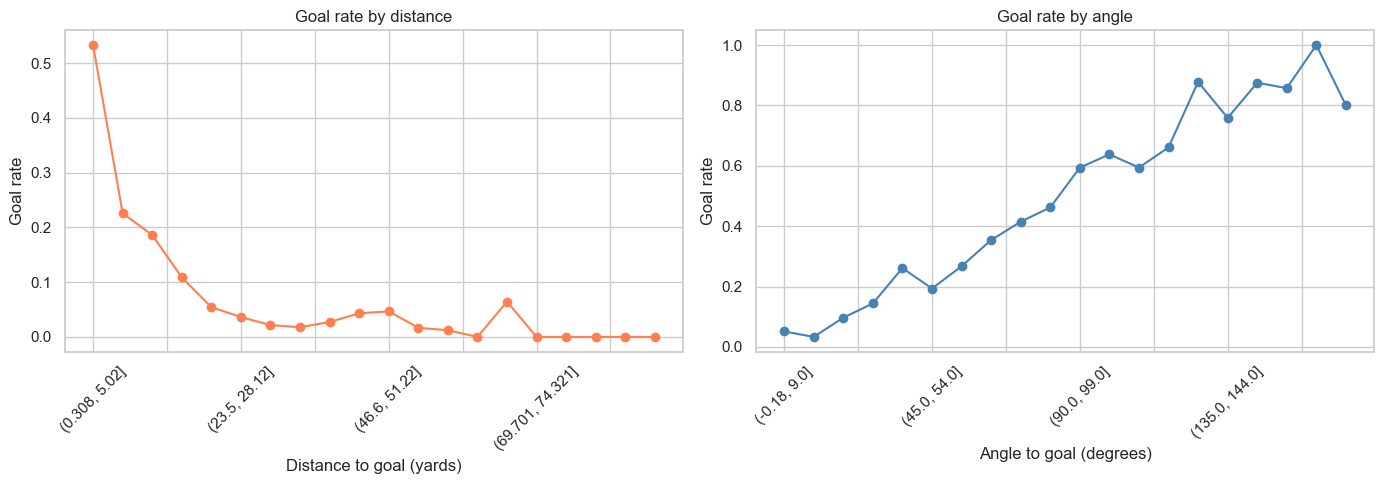

Shots with valid location: 88,023 / 88,023 (100.0%)


In [8]:
# Goal rate by distance and angle bins
valid = df.dropna(subset=["distance_to_goal", "angle_to_goal_deg"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance
valid["distance_bin"] = pd.cut(valid["distance_to_goal"], bins=20)
dist_goal_rate = valid.groupby("distance_bin", observed=True)["shot_outcome"].apply(lambda x: (x == "Goal").mean())
dist_goal_rate.plot(ax=axes[0], marker="o", color="coral")
axes[0].set_xlabel("Distance to goal (yards)")
axes[0].set_ylabel("Goal rate")
axes[0].set_title("Goal rate by distance")
axes[0].tick_params(axis="x", rotation=45)

# Angle
valid["angle_bin"] = pd.cut(valid["angle_to_goal_deg"], bins=20)
angle_goal_rate = valid.groupby("angle_bin", observed=True)["shot_outcome"].apply(lambda x: (x == "Goal").mean())
angle_goal_rate.plot(ax=axes[1], marker="o", color="steelblue")
axes[1].set_xlabel("Angle to goal (degrees)")
axes[1].set_ylabel("Goal rate")
axes[1].set_title("Goal rate by angle")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Shots with valid location: {len(valid):,} / {len(df):,} ({len(valid)/len(df):.1%})")

## Shot outcome breakdown

shot_outcome
Off T               28466
Blocked             21677
Saved               20788
Goal                 9790
Wayward              4823
Post                 1842
Saved Off Target      349
Saved to Post         288
Name: count, dtype: int64

Goal rate (base rate): 11.1%


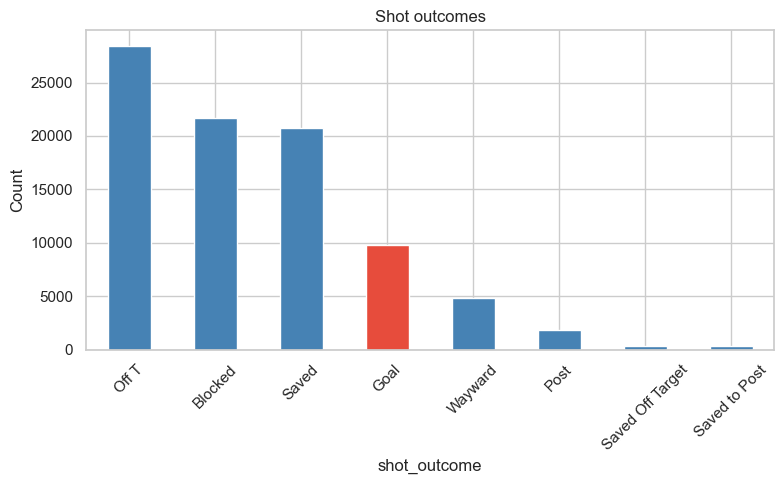

In [9]:
# Outcome distribution
outcome_counts = df["shot_outcome"].value_counts()
print(outcome_counts)
print(f"\nGoal rate (base rate): {(outcome_counts.get('Goal', 0) / outcome_counts.sum()):.1%}")

fig, ax = plt.subplots(figsize=(8, 5))
outcome_counts.plot.bar(ax=ax, color=["#e74c3c" if x == "Goal" else "steelblue" for x in outcome_counts.index])
ax.set_ylabel("Count")
ax.set_title("Shot outcomes")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Penalties vs open play

In [10]:
# Penalties have a very different dynamic — worth understanding separately
is_penalty = df["shot_type"] == "Penalty"
print(f"Penalties: {is_penalty.sum():,} ({is_penalty.mean():.1%} of all shots)")
print(f"Penalty conversion rate: {df.loc[is_penalty, 'shot_outcome'].eq('Goal').mean():.1%}")
print(f"Non-penalty goal rate: {df.loc[~is_penalty, 'shot_outcome'].eq('Goal').mean():.1%}")
print()
print("Play pattern distribution (non-penalties):")
print(df.loc[~is_penalty, "play_pattern"].value_counts().to_string())

Penalties: 1,361 (1.5% of all shots)
Penalty conversion rate: 73.3%
Non-penalty goal rate: 10.1%

Play pattern distribution (non-penalties):
play_pattern
Regular Play      29180
From Free Kick    18018
From Throw In     15502
From Corner       14084
From Counter       3979
From Goal Kick     3340
From Keeper        1388
From Kick Off      1006
Other               165


## Key takeaways

Summarise findings here after running:
- Total dataset size and goal rate (base rate)
- Which competitions have the most data
- Data quality: any missing fields to handle?
- Distance and angle are clearly predictive — good baseline features
- Penalties should be handled separately (or excluded) — very different conversion rate
- Set pieces vs open play have different dynamics